# Detection Rate Calculator

In [ ]:
# --- Installation & Setup (Colab only) ---

import sys

# Check if the env run under Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Clone our GitHub repository into the Colab environment
    !git clone https://github.com/weizmannk/cbc-population-distributions.git
    %cd cbc-population-distributions

    # Install uv (fast dependency manager) and sync dependencies from uv.lock
    !pip install -q uv
    !uv sync

    # (Optional) Add the repo to PYTHONPATH if it's not an installable package

    import glob
    import os

    pyver = f"{sys.version_info.major}.{sys.version_info.minor}"
    venv_site = glob.glob(f".venv/lib/python{pyver}/site-packages")[0]
    sys.path.insert(0, os.path.abspath(venv_site))

    print("Environment ready. You can now run the rest of the notebook.")



## Imports and Setup

In [ ]:
import logging

import numpy as np
from astropy import units as u
from astropy.table import Table
from IPython.display import Markdown, display

from scipy import stats
from astropy.cosmology import Planck15 as cosmo
from astropy.cosmology import z_at_value

# Import Poisson utility functions
if IN_COLAB:
    from scripts.poisson_rate_utils import format_with_errorbars, poisson_lognormal_rate_quantiles
else:
    from poisson_rate_utils import format_with_errorbars, poisson_lognormal_rate_quantiles

print("Imports successful")

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(levelname)s] %(message)s",
    stream=sys.stdout,
    force=True,
)

---

## 1. Function Definitions

In [ ]:
def build_rates_table(fiducial_rates, mass_fractions):
    """
    Build a table with fiducial rates adjusted by mass fractions.

    Parameters
    ----------
    fiducial_rates : dict
        Dictionary with population names as keys and rate dicts as values
    mass_fractions : dict
        Dictionary with population names as keys and fractions as values

    Returns
    -------
    rates_table : astropy.table.Table
        Table with adjusted rates
    """
    rows = []
    for pop in ["BNS", "NSBH", "BBH"]:
        row = {"population": pop}
        row.update(fiducial_rates[pop])
        rows.append(row)

    rates_table = Table(rows)

    # Add mass fractions
    rates_table["mass_fraction"] = [
        mass_fractions["BNS"],
        mass_fractions["NSBH"],
        mass_fractions["BBH"],
    ]

    # Adjust rates by mass fractions
    for key in ["lower", "mid", "upper"]:
        rates_table[key] *= rates_table["mass_fraction"]

    # Calculate log-normal parameters (mu and sigma)
    # Assuming log-normal distribution where lower=5% and upper=95%
    rates_table["fiducial_log_rate"] = np.log(rates_table["mid"])

    # For log-normal: 90% interval
    standard_90pct_interval = np.diff(stats.norm.interval(0.9))[0]

    rates_table["fiducial_log_rate_err"] = (
        np.log(rates_table["upper"]) - np.log(rates_table["lower"])
    ) / standard_90pct_interval

    return rates_table


def calculate_detection_rates(
    run_name, run_config, rates_table, prob_quantiles=[0.05, 0.5, 0.95]
):
    """
    Calculate detection rates for a specific observing run.

    Parameters
    ----------
    run_name : str
        Name of the observing run
    run_config : dict
        Dictionary with 'duration', 'sim_rate', and 'detections'
    rates_table : astropy.table.Table
        Table with fiducial rates and parameters
    prob_quantiles : list
        Probability quantiles [lower, median, upper]

    Returns
    -------
    results : dict
        Dictionary with 'low', 'mid', 'high' estimates for each population
    """
    # Convert simulation rate to Gpc^-3 yr^-1
    sim_rate_gpc = (run_config["sim_rate"] / (u.Mpc**3 * u.yr)).to(u.Gpc**-3 * u.yr**-1)

    results = {"low": {}, "mid": {}, "high": {}}

    for pop in ["BNS", "NSBH", "BBH"]:
        # Get rate info for this population
        rates_row = rates_table[rates_table["population"] == pop]

        # Effective rate for this population
        rate = sim_rate_gpc * rates_row["mass_fraction"][0]

        # Calculate mu for this run
        detection_count = run_config["detections"][pop]
        mu = (
            rates_row["fiducial_log_rate"][0]
            + np.log(run_config["duration"])
            + np.log(detection_count / rate.value)
        )
        sigma = rates_row["fiducial_log_rate_err"][0]

        # Calculate quantiles using Poisson-lognormal distribution
        lo, mid, hi = poisson_lognormal_rate_quantiles(
            np.asarray(prob_quantiles), mu, sigma
        )

        # Round
        lo = int(np.floor(lo))
        mid = int(np.round(mid))
        hi = int(np.ceil(hi))

        # Format with error bars
        mid_str, lo_str, hi_str = format_with_errorbars(mid, lo, hi)

        results["low"][pop] = lo_str
        results["mid"][pop] = mid_str
        results["high"][pop] = hi_str

    return results


def format_results_table(all_results, observing_runs):
    """
    Format all results into a display table.

    Parameters
    ----------
    all_results : dict
        Dictionary of results for each run
    observing_runs : dict
        Dictionary of observing run configurations

    Returns
    -------
    results_table : astropy.table.Table
        Formatted table for display
    """
    rows = []
    for run_name, run_stats in all_results.items():
        for pop in ["BNS", "NSBH", "BBH"]:
            rows.append(
                {
                    "run": run_name,
                    "population": pop,
                    "detections": observing_runs[run_name]["detections"][pop],
                    "rate_low": f"-{run_stats['low'][pop]}",
                    "rate_mid": run_stats["mid"][pop],
                    "rate_high": f"+{run_stats['high'][pop]}",
                }
            )

    return Table(
        rows=rows,
        names=("run", "population", "detections", "rate_low", "rate_mid", "rate_high"),
    )


def display_results(results_table, observing_runs):
    """
    Display results in a formatted way.

    Parameters
    ----------
    results_table : astropy.table.Table
        Table with all results
    observing_runs : dict
        Dictionary of observing run configurations
    """
    print("\n" + "=" * 80)
    print("DETECTION RATE RESULTS")
    print("=" * 80)

    for run_name in sorted(set(results_table["run"])):
        run_config = observing_runs[run_name]
        run_data = results_table[results_table["run"] == run_name]

        print(f"\n{'─' * 80}")
        print(f" Run: {run_name}")
        print(f" Duration: {run_config['duration']} years")
        print(f" Sim Rate: {run_config['sim_rate']:.2e} Mpc⁻³ yr⁻¹")
        print(f"{'─' * 80}")
        print(f"{'Population':<12} {'Detected':<12} {'Annual Rate (90% CI)':<30}")
        print(f"{'─' * 80}")

        for row in run_data:
            rate_str = f"{row['rate_mid']} ({row['rate_low']}, {row['rate_high']})"
            print(f"{row['population']:<12} {row['detections']:<12} {rate_str:<30}")

        print(f"{'─' * 80}")

    print("\n" + "=" * 80)
    print("Calculation complete!")
    print("=" * 80 + "\n")


print("Functions defined successfully")

---

## 2. Configuration

### 2.1 Mass Classification Parameters

In [ ]:
# Mass threshold for neutron star classification (Solar masses)

ns_max_mass = 3.0

display(Markdown(rf"Mass threshold: {ns_max_mass} $M_\odot$"))
display(Markdown(rf"- **BNS**: both masses < {ns_max_mass} $M_\odot$"))
display(Markdown(rf"- **NSBH**: one mass $\geq$ {ns_max_mass} $M_\odot$, one < {ns_max_mass} $M_\odot$"))
display(Markdown(rf"- **BBH**: both masses $\geq$ {ns_max_mass} $M_\odot$"))

### 2.2 Fiducial rate parameters (90% credible intervals in Gpc^-3 yr^-1)

 Table 2. Merger rates from GWTC-4 catalog in units Gpc−3, https://arxiv.org/pdf/2508.18083

In [ ]:
# Fiducial rates: 90% credible intervals (Gpc^-3 yr^-1)
fiducial_rates = {
    "BNS": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
    "NSBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
    "BBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
}

display(Markdown("Fiducial merger rates $(Gpc^{-3} yr^{-1}$)"))
for pop, rates in fiducial_rates.items():
    logging.info(
        f"  {pop:4s}: {rates['mid']:.0f} ({rates['lower']:.0f} - {rates['upper']:.0f})"
    )

### 2.3 Mass Fractions (from CBC population model)

In [ ]:
# Mass fractions from CBC PB2P model
# Based on 1 million total CBCs
mass_fractions = {"BNS": 738291 / 1e6, "NSBH": 162187 / 1e6, "BBH": 99522 / 1e6}

total_fraction = sum(mass_fractions.values())
logging.info("Mass fractions from CBC population:")
for pop, frac in mass_fractions.items():
    logging.info(f"  {pop:4s}: {frac:.4f} ({frac * 100:.2f}%)")
logging.info(f" Total: {total_fraction:.4f}")

if abs(total_fraction - 1.0) > 0.01:
    logging.info("\n Warning: Mass fractions don't sum to 1.0")

### 2.4 Observing Runs Configuration

In observing scenarios data there is a file sqlite  file "sqlite3 events.sqlite" where we can read the

the simulation Merger rate, for that use this command line in terminal or import sqlite with python

 Use this command to retrieve comments:

 1- $ sqlite3 events.sqlite

 2- $ select comment from process;


In [ ]:
observing_runs = {
    "O4a_GWTC-4": {
        "duration": 1,  #  Run duration in years,
        "sim_rate": 7.2624879649601604e-06,  # Mpc^-3 yr^-1
        "detections": {"BNS": 234, "NSBH": 282, "BBH": 3304},
    }
}

# Display configured runs
print(f" Configured {len(observing_runs)} observing run(s):\n")
for run_name, config in observing_runs.items():
    total_det = sum(config["detections"].values())
    print(f"  {run_name}:")
    print(f"    Duration: {config['duration']} years")
    print(f"    Sim rate: {config['sim_rate']:.2e} Mpc⁻³ yr⁻¹")
    print(f"    Total detections: {total_det}")
    print(
        f"      BNS={config['detections']['BNS']}, "
        f"NSBH={config['detections']['NSBH']}, "
        f"BBH={config['detections']['BBH']}"
    )

---

## 3. Run the dtection rate

3.1 Build Rates Table

In [ ]:
# Build the rates table
print("Building rates table...")
rates_table = build_rates_table(fiducial_rates, mass_fractions)

print("\nAdjusted Rates Table:")
print("=" * 80)
print(
    rates_table[
        [
            "population",
            "mid",
            "mass_fraction",
            "fiducial_log_rate",
            "fiducial_log_rate_err",
        ]
    ]
)
print("=" * 80)

### 3.2 Calculate detection rates for all Runs

In [ ]:
# Calculate detection rates for all configured runs
print("\nCalculating detection rates...\n")

all_results = {}
for run_name, run_config in observing_runs.items():
    print(f"  Processing {run_name}...", end=" ")

    all_results[run_name] = calculate_detection_rates(run_name, run_config, rates_table)

    print("")

print("\n All calculations complete!")

---

## 4. Results

### 4.1 Create Results Table

In [ ]:
# Format results into a table
results_table = format_results_table(all_results, observing_runs)

print("\nResults Table:")
print("=" * 80)
print(results_table)
print("=" * 80)

### 4.2 Display Formatted Results

In [ ]:
# Display detailed results
display_results(results_table, observing_runs)

### 5.3 Export Results (Optional)

In [ ]:
# # Export to CSV
# output_file = "detection_rates_results.csv"
# results_table.write(output_file, format="csv", overwrite=True)
# print(f"\n Results exported to: {output_file}")

# For Multible distribustion and different Fiducial

In [ ]:
# The run duration in years,
duration = 1

# Define multiple fiducial rate scenarios
fiducial_rate_scenarios = {
    "GWTC-3": {
        "BNS": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "NSBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
        "BBH": {"lower": 100.0, "mid": 240.0, "upper": 510.0},
    },
    "GWTC-4": {
        "BNS": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "NSBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
        "BBH": {"lower": 50.0, "mid": 130.0, "upper": 290.0},
    },
}

# Define mass fraction scenarios
mass_fraction_scenarios = {
    "GWTC-3": {"BNS": 892762 / 1e6, "NSBH": 35962 / 1e6, "BBH": 71276 / 1e6},
    "GWTC-4": {"BNS": 738291 / 1e6, "NSBH": 162187 / 1e6, "BBH": 99522 / 1e6},
}


observing_runs = {
    "O4a_GWTC-3": {
        "duration": duration,  # The run duration in years,
        "sim_rate": 8.209138761890435e-06,
        "detections": {"BNS": 405, "NSBH": 90, "BBH": 4222},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-4": {
        "duration": duration,  # The run duration in years,
        "sim_rate": 7.2624879649601604e-06,
        "detections": {"BNS": 234, "NSBH": 282, "BBH": 3304},
        "scenario": "GWTC-4",
    },
    "O4a_GWTC-3_snr-10_mesurePSD": {
        "duration": duration,  # The run duration in years,
        "sim_rate": 9.761353524686725e-06,
        "detections": {"BNS": 239, "NSBH": 42, "BBH": 2459},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-3_snr-8_mesurePSD": {
        "duration": duration,  # The run duration in years,
        "sim_rate": 9.761353524686725e-06,
        "detections": {"BNS": 490, "NSBH": 89, "BBH": 4701},
        "scenario": "GWTC-3",
    },
    "O4a_GWTC-4_snr-8_mesurePSD": {
        "duration": duration,  # The run duration in years,
        "sim_rate": 6.8706584586426236e-06,
        "detections": {"BNS": 211, "NSBH": 238, "BBH": 2964},
        "scenario": "GWTC-4",
    },
}

In [ ]:
all_results = {}
for run_name, run_config in observing_runs.items():
    print(f"  Processing {run_name}...", end=" ")

    # Get the appropriate scenario
    scenario = run_config["scenario"]

    # Build rates table for this scenario
    rates_table = build_rates_table(
        fiducial_rate_scenarios[scenario], mass_fraction_scenarios[scenario]
    )

    # Calculate detection rates
    all_results[run_name] = calculate_detection_rates(run_name, run_config, rates_table)

  Processing O4a_GWTC-3...   Processing O4a_GWTC-4...   Processing O4a_GWTC-3_snr-10_mesurePSD...   Processing O4a_GWTC-3_snr-8_mesurePSD...   Processing O4a_GWTC-4_snr-8_mesurePSD... 

In [ ]:
# Format ALL results into a single table
results_table = format_results_table(all_results, observing_runs)

print("\nResults Table:")
print("=" * 80)
print(results_table)
print("=" * 80)


Results Table:
            run             population detections rate_low rate_mid rate_high
--------------------------- ---------- ---------- -------- -------- ---------
                 O4a_GWTC-3        BNS        405       -8       11       +17
                 O4a_GWTC-3       NSBH         90       -2        2        +4
                 O4a_GWTC-3        BBH       4222      -71      123      +157
                 O4a_GWTC-4        BNS        234       -4        4        +7
                 O4a_GWTC-4       NSBH        282       -4        4       +10
                 O4a_GWTC-4        BBH       3304      -37       59       +85
O4a_GWTC-3_snr-10_mesurePSD        BNS        239       -5        5       +10
O4a_GWTC-3_snr-10_mesurePSD       NSBH         42       -0        0        +0
O4a_GWTC-3_snr-10_mesurePSD        BBH       2459      -36       60       +78
 O4a_GWTC-3_snr-8_mesurePSD        BNS        490       -9       12       +17
 O4a_GWTC-3_snr-8_mesurePSD       NSBH         8

In [ ]:
# Display detailed results for all runs
display_results(results_table, observing_runs)


DETECTION RATE RESULTS

────────────────────────────────────────────────────────────────────────────────
 Run: O4a_GWTC-3
 Duration: 1 years
 Sim Rate: 8.21e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Annual Rate (90% CI)          
────────────────────────────────────────────────────────────────────────────────
BNS          405          11 (-8, +17)                  
NSBH         90           2 (-2, +4)                    
BBH          4222         123 (-71, +157)               
────────────────────────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────────────────────────
 Run: O4a_GWTC-3_snr-10_mesurePSD
 Duration: 1 years
 Sim Rate: 9.76e-06 Mpc⁻³ yr⁻¹
────────────────────────────────────────────────────────────────────────────────
Population   Detected     Annual Rate (90% CI)          
────────────────────────────────────────────────────

In [ ]:
output_file = "detection_rates_results.csv"
results_table.write(output_file, format="csv", overwrite=True)
print(f"\n Results exported to: {output_file}")


 Results exported to: detection_rates_results.csv


## He we wan to compare O4a Observations vs Population Model Predictions (90% Credible Intervals)

[INFO] NumExpr defaulting to 2 threads.


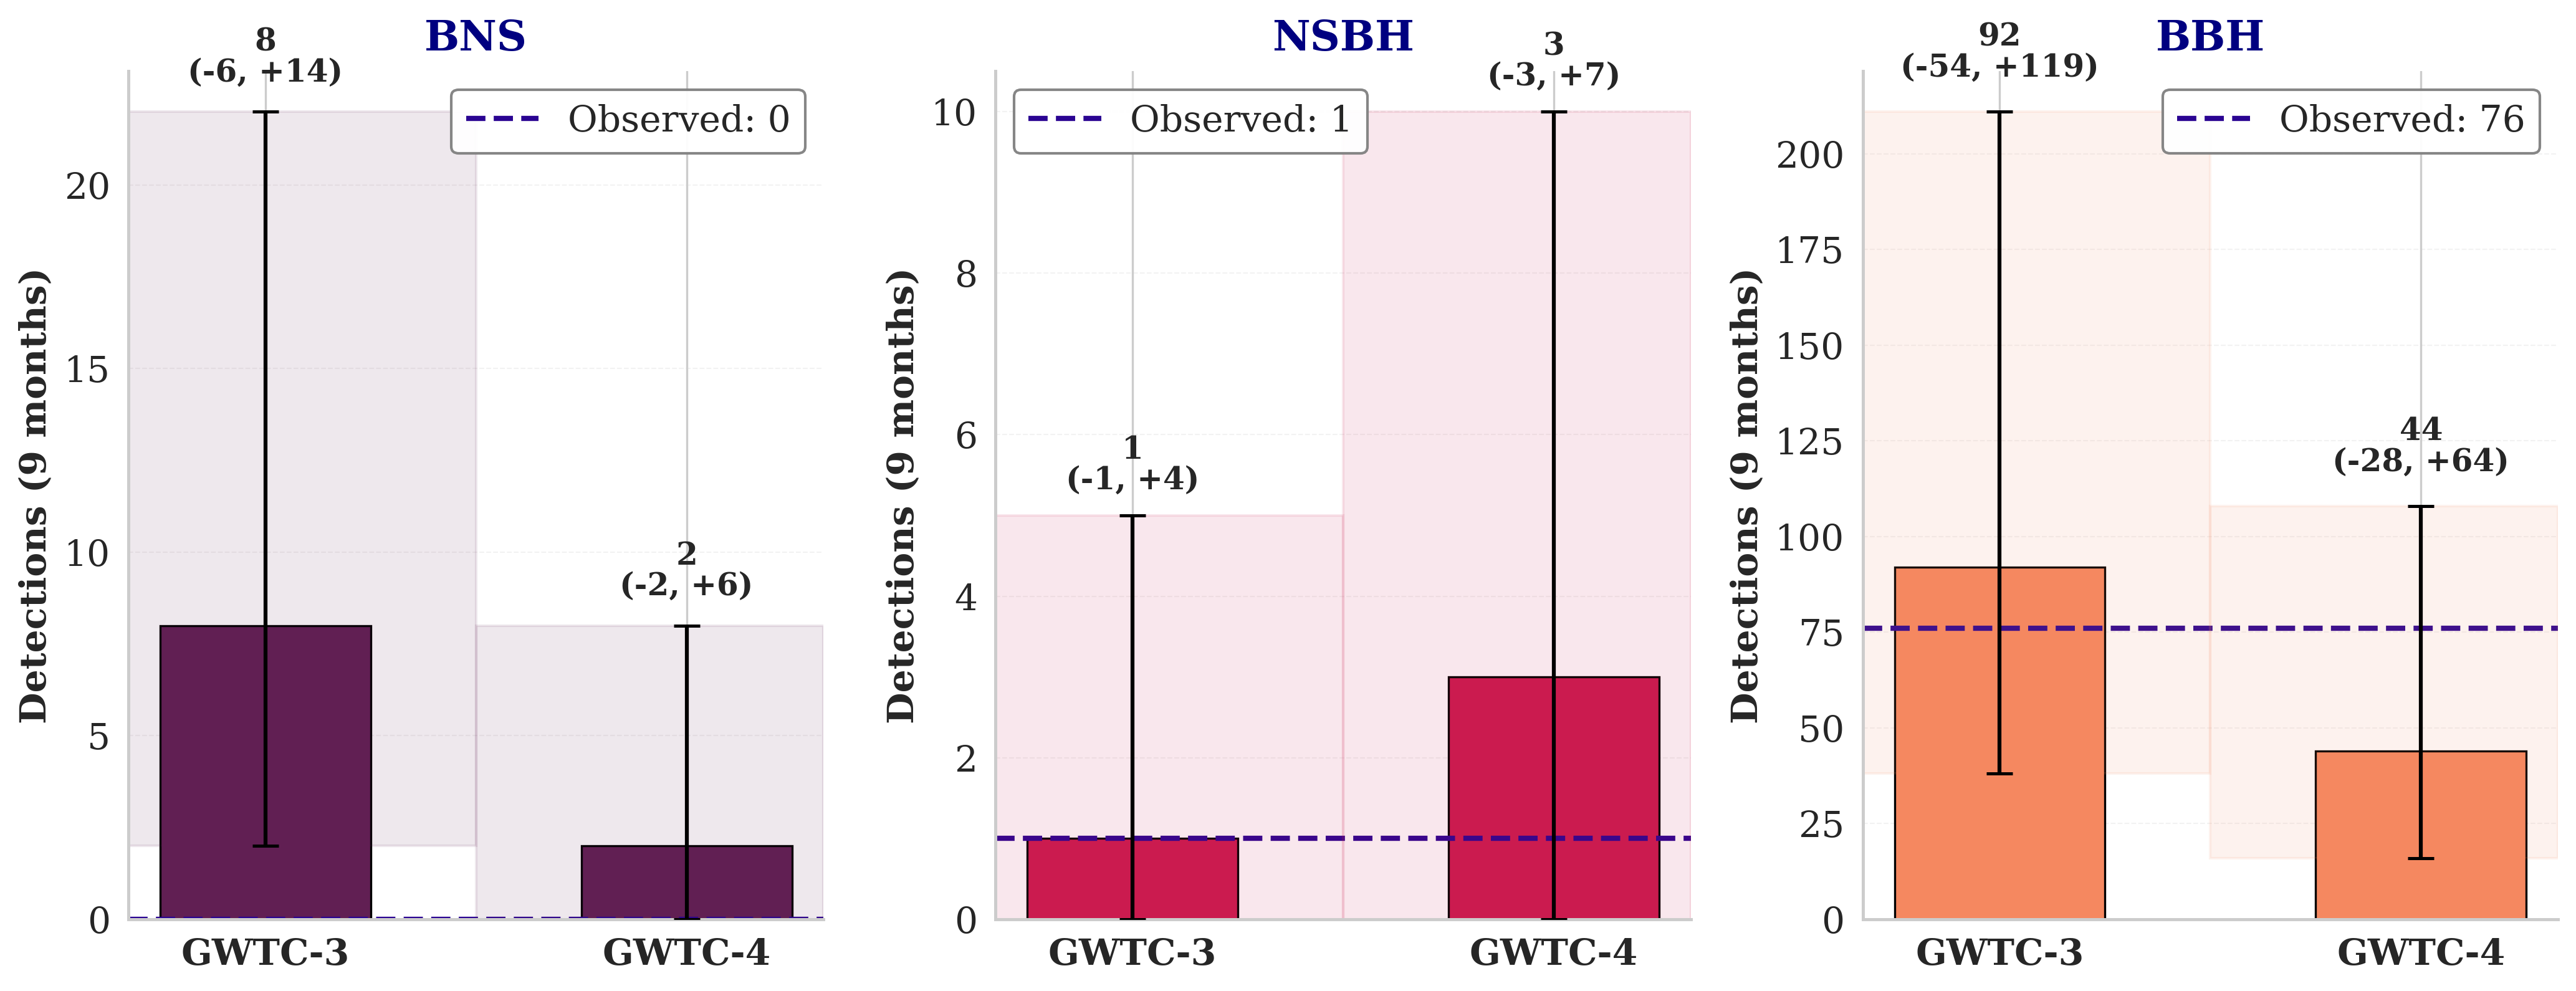

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
plt.rcParams["font.size"] = 14
plt.rcParams["axes.linewidth"] = 1.2

bns_color, nsbh_color, bbh_color = sns.color_palette("rocket", 3)


MODEL_NAMES = {"Model_A": "GWTC-3", "Model_B": "GWTC-4"}

# Data for 9 months O4a
data = {
    "Model_A": {
        "BNS": {"mid": 8, "lower_delta": -6, "upper_delta": 14},
        "NSBH": {"mid": 1, "lower_delta": -1, "upper_delta": 4},
        "BBH": {"mid": 92, "lower_delta": -54, "upper_delta": 119},
    },
    "Model_B": {
        "BNS": {"mid": 2, "lower_delta": -2, "upper_delta": 6},
        "NSBH": {"mid": 3, "lower_delta": -3, "upper_delta": 7},
        "BBH": {"mid": 44, "lower_delta": -28, "upper_delta": 64},
        # "BNS": {"mid": 2, "lower_delta": -2, "upper_delta": 6},
        # "NSBH": {"mid": 2, "lower_delta": -2, "upper_delta": 7},
        # "BBH": {"mid": 42, "lower_delta": -27, "upper_delta": 61},
    },
    "Observed": {"BNS": 0, "NSBH": 1, "BBH": 76},
}

populations = ["BNS", "NSBH", "BBH"]
colors_pop = {"BNS": bns_color, "NSBH": nsbh_color, "BBH": bbh_color}

models = ["Model_A", "Model_B"]

# Bounds
for model in models:
    for pop in populations:
        mid = data[model][pop]["mid"]
        lower_delta = data[model][pop]["lower_delta"]
        upper_delta = data[model][pop]["upper_delta"]
        data[model][pop]["low"] = mid + lower_delta
        data[model][pop]["high"] = mid + upper_delta


fig, axes = plt.subplots(1, 3, figsize=(14, 6), dpi=300)

for idx, pop in enumerate(populations):
    ax = axes[idx]

    x_pos = np.arange(2)
    predictions = []
    err_low = []
    err_high = []

    for model in models:
        mid = data[model][pop]["mid"]
        low = data[model][pop]["low"]
        high = data[model][pop]["high"]
        predictions.append(mid)
        err_low.append(mid - low)
        err_high.append(high - mid)

    # Plot bars
    bars = ax.bar(
        x_pos,
        predictions,
        width=0.5,
        color=colors_pop[pop],
        alpha=1,
        edgecolor="black",
        linewidth=0.8,
    )

    # Error bars
    ax.errorbar(
        x_pos,
        predictions,
        yerr=[err_low, err_high],
        fmt="none",
        ecolor="black",
        capsize=5,
        capthick=1.2,
        linewidth=1.5,
        zorder=5,
    )

    # Observed line
    obs_value = data["Observed"][pop]
    ax.axhline(
        y=obs_value,
        color="#2A0492",
        linestyle="--",
        linewidth=2,
        label=f"Observed: {obs_value}",
        zorder=1,
        alpha=1,
    )

    # Shaded CI regions
    for i, model in enumerate(models):
        low = data[model][pop]["low"]
        high = data[model][pop]["high"]
        ax.axhspan(
            low,
            high,
            xmin=i / 2,
            xmax=(i + 1) / 2,
            alpha=0.1,
            color=colors_pop[pop],
            zorder=1,
        )

    # Add numerical labels: value (lower_delta, upper_delta)
    for i, (bar, val) in enumerate(zip(bars, predictions)):
        height = bar.get_height()
        model = models[i]
        lower_delta = data[model][pop]["lower_delta"]
        upper_delta = data[model][pop]["upper_delta"]

        text_y = height + err_high[i] + max(predictions) * 0.08
        label_text = f"{val}\n({lower_delta:+d}, {upper_delta:+d})"

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y,
            label_text,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            linespacing=1,
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [MODEL_NAMES[m] for m in models], fontsize=14, rotation=0, fontweight="bold"
    )
    ax.set_ylabel("Detections (9 months)", fontsize=14, fontweight="bold")
    ax.set_title(f"{pop}", fontsize=16, fontweight="bold", pad=8, color="navy")
    ax.legend(fontsize=14, framealpha=0.95, edgecolor="gray")
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.5)
    ax.set_ylim(bottom=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# fig.text(0.5, 0.02, 'Population Model', ha='center', fontsize=10, fontweight='bold')
# fig.suptitle('O4a Observations vs Population Model Predictions\n(90% Credible Intervals)',
#               fontsize=11, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig(
    "model-prediction_vs_Observation.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.savefig(
    "model-prediction_vs_Observation.pdf", bbox_inches="tight", facecolor="white"
)
plt.show()

In [38]:
# # ============================================================================
# # Load and process data
# # ============================================================================
# table = Table.read("injections-O4a-GWTC-4-ideal-psd.dat", format="ascii.fast_tab")
# ns_max_mass = 3

# # Split by source frame mass
# z = z_at_value(cosmo.luminosity_distance, table["distance"] * u.Mpc).to_value(
#     u.dimensionless_unscaled
# )
# zp1 = z + 1
# source_mass1 = table["mass1"] / zp1
# source_mass2 = table["mass2"] / zp1
# # ============================================================================
# # Print population statistics
# # ============================================================================

# print(
#     f"Number of BNS: {np.sum((source_mass1 < ns_max_mass) & (source_mass2 < ns_max_mass))}, "
#     f"Number of NSBH: {np.sum((source_mass1 >= ns_max_mass) & (source_mass2 < ns_max_mass))}, "
#     f"Number of BBH: {np.sum((source_mass1 >= ns_max_mass) & (source_mass2 >= ns_max_mass))}"
# )